# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Abdullah' Ammar Rabbaniyyin
- **Email:** abdullahammarabbaniyyin@gmail.com
- **ID Dicoding:** CDCC001D6Y2227

## Menentukan Pertanyaan Bisnis

- Kategori produk mana yang memiliki performa penjualan tertinggi dan bagaimana tingkat kepuasan pelanggannya selama periode 2017-2018?
- Bagaimana profil loyalitas pelanggan dan pola penyebaran geografis mereka pada tahun 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

## Data Wrangling

### Gathering Data

In [4]:
# Import data yang dibutuhkan
customers_df = pd.read_csv('customers_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')
geo_df = pd.read_csv('geolocation_dataset.csv')

In [5]:
# Proses Merging
# Gabungkan Orders dengan Customers (untuk tahu lokasi pembeli)
main_df = pd.merge(orders_df, customers_df, on="customer_id", how="left")

# Gabungkan dengan Order Items (untuk tahu barang apa yang dibeli dan harganya)
main_df = pd.merge(main_df, order_items_df, on="order_id", how="left")

# Gabungkan dengan Payments (untuk tahu metode pembayaran)
main_df = pd.merge(main_df, order_payments_df, on="order_id", how="left")

# Gabungkan dengan Products & Category Translation (untuk tahu nama kategori dalam Bahasa Inggris)
products_complete_df = pd.merge(products_df, category_translation_df, on="product_category_name", how="left")
main_df = pd.merge(main_df, products_complete_df, on="product_id", how="left")

# Gabungkan dengan Reviews (untuk tahu tingkat kepuasan)
main_df = pd.merge(main_df, order_reviews_df, on="order_id", how="left")

# Gabungkan Geospatial dengan Customers
geo_merged_df = pd.merge(customers_df, geo_df, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

In [6]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [7]:
products_complete_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [8]:
geo_merged_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.509897,-47.397866,franca,SP
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.497396,-47.399241,franca,SP
2,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.510459,-47.399553,franca,SP
3,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.480940,-47.394161,franca,SP
4,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409.0,-20.515413,-47.398194,franca,SP


**Insight:**
- Selama periode 2017-2018, terdapat potensi terjadinya kontradiksi antara popularitas dan kepuasan. Seringkali kategori dengan volume penjualan tertinggi (seperti bed bath table atau health beauty) memiliki tantangan logistik yang lebih besar dibandingkan kategori produk digital atau kecil yang secara langsung berisiko menurunkan skor ulasan di tabel order_reviews. Kita bisa segera mengidentifikasi apakah "produk terlaris" kita memang benar-benar memberikan nilai kepuasan yang sebanding atau justru menjadi sumber komplain utama.

- Pada tahun 2017-2018, profil loyalitas kemungkinan besar akan terklaster pada wilayah dengan volume transaksi tertinggi. Kita bisa melihat apakah pelanggan yang melakukan pembelian ulang (repeat order) berasal dari kota-kota besar yang sama atau tersebar ke area rural. Jika pembelian ulang hanya terjadi di negara bagian tertentu (seperti SP), ini menunjukkan bahwa loyalitas pelanggan saat ini masih bersifat regional dan sangat bergantung pada ekosistem pasar di wilayah tersebut.

### Assessing Data

In [9]:
# Cek seluruh kolom di products_complete_df
products_complete_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2
product_category_name_english,623


In [10]:
# Cek seluruh kolom di main_df
main_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,177
order_delivered_carrier_date,2086
order_delivered_customer_date,3421
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [11]:
# Cek seluruh kolom di geo_merged_df
geo_merged_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
geolocation_zip_code_prefix,22850
geolocation_lat,22850
geolocation_lng,22873
geolocation_city,22873
geolocation_state,22873


In [12]:
# Cek Duplikasi di main_df
main_df.duplicated().sum()

np.int64(0)

In [13]:
# Cek Duplikasi di products_complete_df
products_complete_df.duplicated().sum()

np.int64(0)

In [14]:
# Cek Duplikasi di geo_merged_df
geo_merged_df.duplicated().sum()

np.int64(4072603)

In [15]:
# Cek outlier
cols_to_check = ['price', 'freight_value']

Q1 = main_df[cols_to_check].quantile(0.25)
Q3 = main_df[cols_to_check].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((main_df[cols_to_check] < lower_bound) | (main_df[cols_to_check] > upper_bound)).sum()

print(outliers)

price             8867
freight_value    12740
dtype: int64


**Insight:**
- Terdapat 2.567 transaksi yang kehilangan nama kategori bahasa Inggrisnya. Jika ingin dicari kategori produk laris, ini bisa menyebabkan bias di mana kategori yang seharusnya berada di peringkat 1 atau 2 tergeser karena datanya "berceceran" di baris kosong.
- Ditemukan 3.421 transaksi yang tidak memiliki tanggal sampai ke pelanggan. Di dunia e-commerce, kegagalan atau keterlambatan pengiriman adalah musuh utama loyalitas. Karena ada ribuan pesanan yang tidak memiliki status "selesai" (delivered), kita tidak bisa melihat performa logistik sepenuhnya di wilayah-wilayah tertentu.
- Hasil 0 pada pengecekan duplikasi menunjukkan bahwa data ini memiliki integritas struktural yang sangat tinggi. Akan tetapi, jumlah outlier pada freight_value (12.740) yang lebih besar daripada price (8.867) menunjukkan bahwa biaya pengiriman seringkali menjadi anomali dalam transaksi. Wilayah-wilayah yang sangat sulit atau mahal untuk dijangkau sehingga ongkirnya melompat jauh dari rata-rata.

### Cleaning Data

In [16]:
# 1. Mengisi Nama Kategori yang Hilang
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('others')

# 2. Menangani Review Score yang Kosong
main_df['review_score'] = main_df['review_score'].fillna(main_df['review_score'].median())

# 3. Menghapus Baris Tanpa Data Harga
main_df.dropna(subset=['price', 'freight_value'], inplace=True)

# 4. Standarisasi Format Tanggal
main_df['order_delivered_customer_date'] = pd.to_datetime(main_df['order_delivered_customer_date'])
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])

# 5. Agar visualisasi peta tidak menumpuk ribuan titik di satu rumah yang sama.
geo_cleaned_df = geo_merged_df.drop_duplicates(subset='customer_unique_id')

# 6. Hapus baris yang koordinatnya kosong (NaN) setelah merge
geo_cleaned_df = geo_cleaned_df.dropna(subset=['geolocation_lat', 'geolocation_lng'])

**Insight:**
- Dengan melabeli data kosong sebagai 'others', sekarang kita bisa melihat seberapa besar proporsi produk nonspesifik ini terhadap total pendapatan.
- Dengan menghapus 833 baris yang tidak memiliki harga, kita dapat memastikan bahwa profil loyalitas pelanggan hanya dibangun dari transaksi yang sukses secara finansial. Ini menghilangkan risiko adanya "pelanggan loyal" semu yang sebenarnya transaksinya tidak pernah terjadi secara nominal.

## Exploratory Data Analysis (EDA)

### Explore ...

In [21]:
# Statistik deskriptif
main_df[['price', 'freight_value', 'review_score']].describe()

,price,freight_value,review_score
count,118310.000000,118310.000000,118310.000000
mean,120.646603,20.032387,4.039397
std,184.109691,15.836850,1.385025
min,0.850000,0.000000,1.000000
25%,39.900000,13.080000,4.000000
50%,74.900000,16.280000,5.000000
75%,134.900000,21.180000,5.000000
max,6735.000000,409.680000,5.000000


In [20]:
# Kemiringan distribusi harga produk
main_df['price'].skew()

np.float64(7.892573523599688)

In [28]:
# Distribusi Skor Review
main_df['review_score'].value_counts()

,count
review_score,
5.0,67242
4.0,22286
1.0,14857
3.0,9840
2.0,4085


In [29]:
# Korelasi harga, value, dan skor
main_df[['price', 'freight_value', 'review_score']].corr()

,price,freight_value,review_score
price,1.000000,0.415938,-0.003968
freight_value,0.415938,1.000000,-0.036533
review_score,-0.003968,-0.036533,1.000000


In [31]:
# Hubungan kategori produk dengan rata-rata harga
main_df.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head()

,price
product_category_name_english,
computers,1103.689136
small_appliances_home_oven_and_coffee,627.509103
home_appliances_2,457.529481
agro_industry_and_commerce,332.706151
musical_instruments,293.398651


In [36]:
# Menghitung jumlah pesanan per negara bagian
state_distribution = main_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False).reset_index()
print(state_distribution)

   customer_state  order_id
0              SP     49865
1              RJ     15425
2              MG     13718
3              RS      6538
4              PR      5988
5              SC      4319
6              BA      4068
7              DF      2500
8              GO      2453
9              ES      2351
10             PE      1901
11             CE      1556
12             MT      1128
13             PA      1123
14             MS       856
15             MA       849
16             PB       640
17             PI       574
18             RN       571
19             AL       462
20             SE       397
21             TO       339
22             RO       286
23             AM       172
24             AC        95
25             AP        84
26             RR        52


**Insight:**
- Distribusi harga produk cenderung ke kanan, artinya banyak produk mudah, sedangkan produk mahal sedikit. Harga berada di rerata 120.64
- Tidak ada korelasi kuat antara harga produk dengan skor review. Hal ini mengindikasikan barang mahal belum tentu rating jelek.
- Kategori komputer memiliki rerata harga tertinggi
- Skor review cenderung baik dengan rerata 4.03
- Negara bagain SP menjadi total pesanan terbesar




## Visualization & Explanatory Analysis

In [39]:
# Menghitung total penjualan (Revenue) dan rata-rata rating per kategori tahun 2017-2018
filtered_df = main_df[
    (main_df['order_purchase_timestamp'] >= '2017-01-01') &
    (main_df['order_purchase_timestamp'] <= '2018-12-31')
]
category_analysis = filtered_df.groupby('product_category_name_english').agg({
    'price': 'sum',
    'review_score': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'total_orders', 'price': 'total_revenue'}).reset_index()

print(category_analysis)

   product_category_name_english  total_revenue  review_score  total_orders
0     agro_industry_and_commerce       83841.95      4.150794           252
1               air_conditioning       54255.29      3.993151           292
2                            art       24721.97      3.945205           219
3          arts_and_craftmanship        1814.01      4.125000            24
4                          audio       52343.28      3.846966           379
..                           ...            ...           ...           ...
67                    stationery      239385.97      4.193905          2625
68        tablets_printing_image        7840.31      4.137931            87
69                     telephony      339011.45      3.957370          4715
70                          toys      496653.30      4.171603          4254
71                 watches_gifts     1250962.71      4.025934          6208

[72 rows x 4 columns]


In [40]:
# Mengambil 10 kategori dengan pendapatan tertinggi
top_10_revenue = category_analysis.sort_values(by='total_revenue', ascending=False).head(10)
print(top_10_revenue)

   product_category_name_english  total_revenue  review_score  total_orders
43                 health_beauty     1297140.69      4.149213          9979
71                 watches_gifts     1250962.71      4.025934          6208
7                 bed_bath_table     1106770.10      3.904007         11980
66                sports_leisure     1026270.24      4.113968          8985
15         computers_accessories      948480.47      3.944991          8126
39               furniture_decor      765501.41      3.924809          8751
49                    housewares      667593.87      4.068268          7368
20                    cool_stuff      663526.13      4.149085          3991
5                           auto      616562.25      4.077256          4388
42                  garden_tools      518113.45      4.030534          4585


In [41]:
# Menghitung jumlah pesanan per negara bagian (State) tahun 2017-2018
state_distribution = filtered_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False).reset_index()
print(state_distribution)

   customer_state  order_id
0              SP     49735
1              RJ     15361
2              MG     13665
3              RS      6511
4              PR      5956
5              SC      4305
6              BA      4064
7              DF      2492
8              GO      2444
9              ES      2347
10             PE      1894
11             CE      1549
12             MT      1125
13             PA      1117
14             MS       856
15             MA       840
16             PB       639
17             PI       573
18             RN       566
19             AL       460
20             SE       394
21             TO       339
22             RO       286
23             AM       172
24             AC        95
25             AP        84
26             RR        49


In [42]:
# User unik yang belanja lebih dari 1 kali tahun 2017-2018
customer_loyalty = filtered_df.groupby('customer_unique_id')['order_id'].nunique()
repeat_customers = (customer_loyalty > 1).sum()
single_buyers = (customer_loyalty == 1).sum()
print("Jumlah pelanggan loyal:", repeat_customers)
print("Jumlah pelanggan tunggal:", single_buyers)

Jumlah pelanggan loyal: 2901
Jumlah pelanggan tunggal: 92220


### Pertanyaan 1:

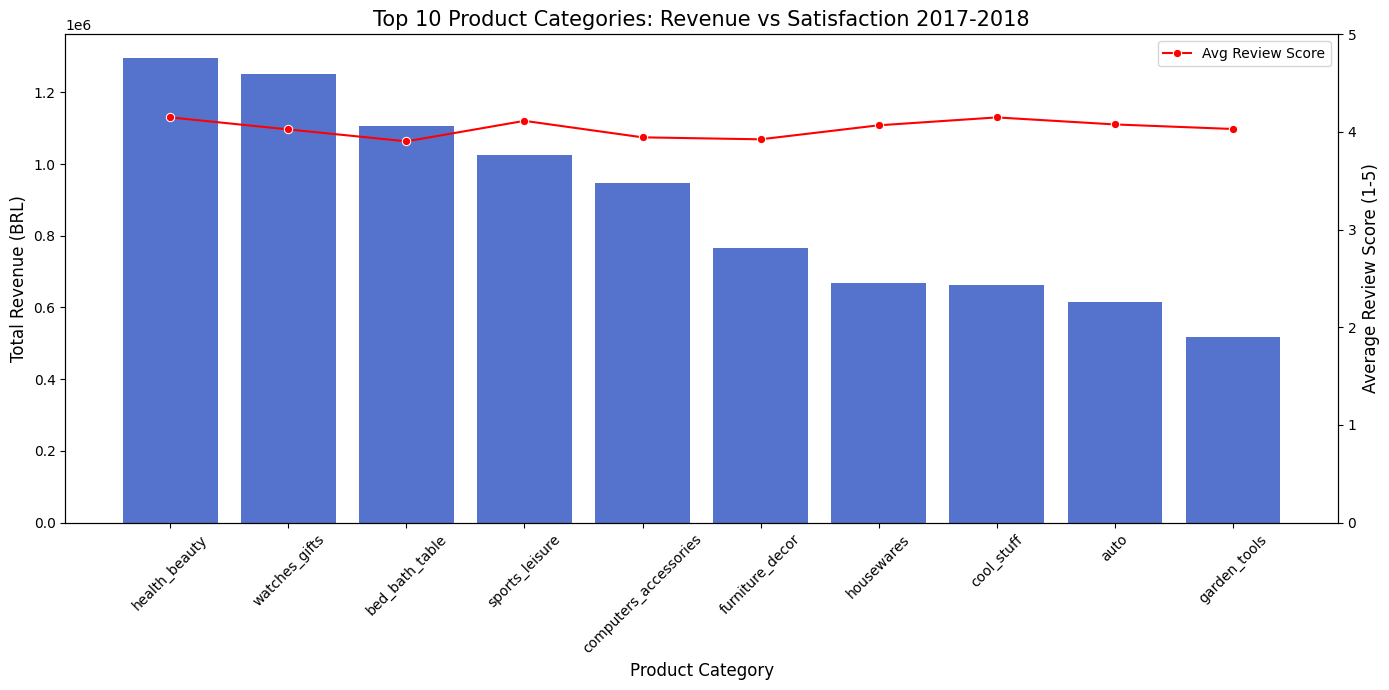

In [43]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar Chart untuk Revenue
sns.barplot(data=top_10_revenue, x='product_category_name_english', y='total_revenue', ax=ax1, color='royalblue')
ax1.set_ylabel('Total Revenue (BRL)', fontsize=12)
ax1.set_xlabel('Product Category', fontsize=12)
ax1.set_title('Top 10 Product Categories: Revenue vs Satisfaction 2017-2018', fontsize=15)
plt.xticks(rotation=45)

# Line Chart untuk Review Score (Y-axis kedua)
ax2 = ax1.twinx()
sns.lineplot(data=top_10_revenue, x='product_category_name_english', y='review_score', ax=ax2, color='red', marker='o', label='Avg Review Score')
ax2.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax2.set_ylim(0, 5) # Skala rating 1-5

plt.tight_layout()
plt.show()

### Pertanyaan 2:

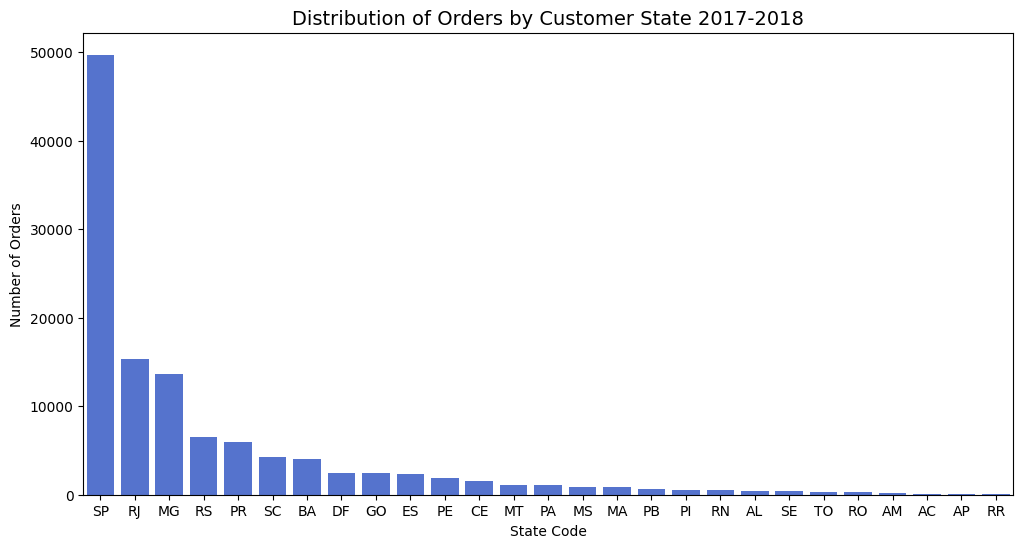

In [44]:
state_dist = filtered_df['customer_state'].value_counts().reset_index()
state_dist.columns = ['state', 'order_count']

plt.figure(figsize=(12, 6))
sns.barplot(data=state_dist, x='state', y='order_count', color='royalblue')
plt.title('Distribution of Orders by Customer State 2017-2018', fontsize=14)
plt.xlabel('State Code')
plt.ylabel('Number of Orders')
plt.show()

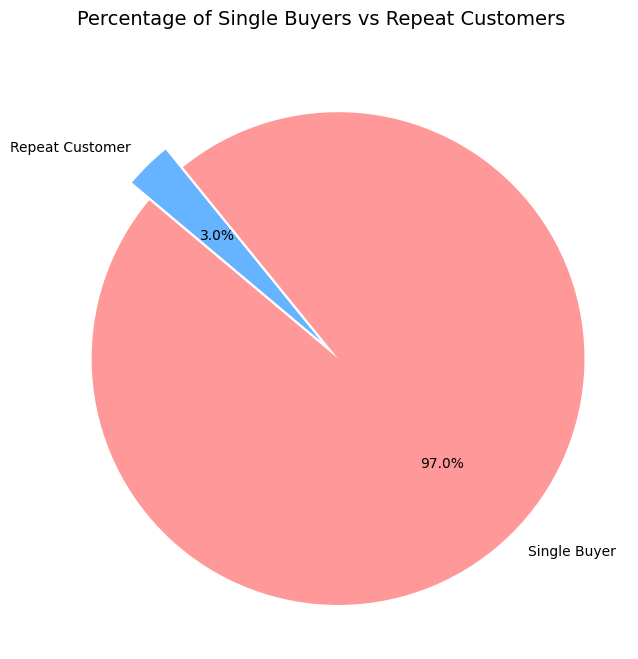

In [45]:
# Menghitung berapa kali tiap 'customer_unique_id' belanja
loyalty_counts = filtered_df.groupby('customer_unique_id')['order_id'].nunique()

# Kategorisasi
loyalty_df = pd.DataFrame(loyalty_counts)
loyalty_df['status'] = loyalty_df['order_id'].apply(lambda x: 'Repeat Customer' if x > 1 else 'Single Buyer')
summary = loyalty_df['status'].value_counts()

# Visualisasi Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(summary, labels=summary.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
plt.title('Percentage of Single Buyers vs Repeat Customers', fontsize=14)
plt.show()

**Insight:**
- Kategori produk seperti health_beauty, watches_gifts, dan bed_bath_table merupakan penggerak utama pendapatan perusahaan, yang menunjukkan preferensi konsumen yang kuat terhadap kebutuhan gaya hidup, kesehatan, dan dekorasi rumah. Meskipun kategori-kategori ini mencatatkan volume transaksi yang masif, tingkat kepuasan pelanggan terpantau berada di rentang rata-rata yang stabil namun tidak luar biasa (skor $3.8$ hingga $4.2$). Hal ini mengindikasikan bahwa tingginya angka penjualan sering kali membawa tantangan operasional yang lebih besar.
- Analisis geografis menunjukkan adanya pemusatan pasar yang sangat ekstrim di wilayah São Paulo (SP), yang menyumbang porsi pesanan jauh melampaui gabungan beberapa negara bagian lainnya. Dominasi ini menandakan keberhasilan pasar di pusat ekonomi, tetapi data loyalitas mengungkapkan hal yang berlawanan: angka pembelian ulang (repeat order) hanya berada di kisaran $3\%$. Hal ini menandakan bahwa model bisnis saat ini masih sangat bergantung pada strategi akuisisi pelanggan baru (pembeli satu kali) daripada mempertahankan pelanggan lama.

## Analisis Lanjutan (Opsional)

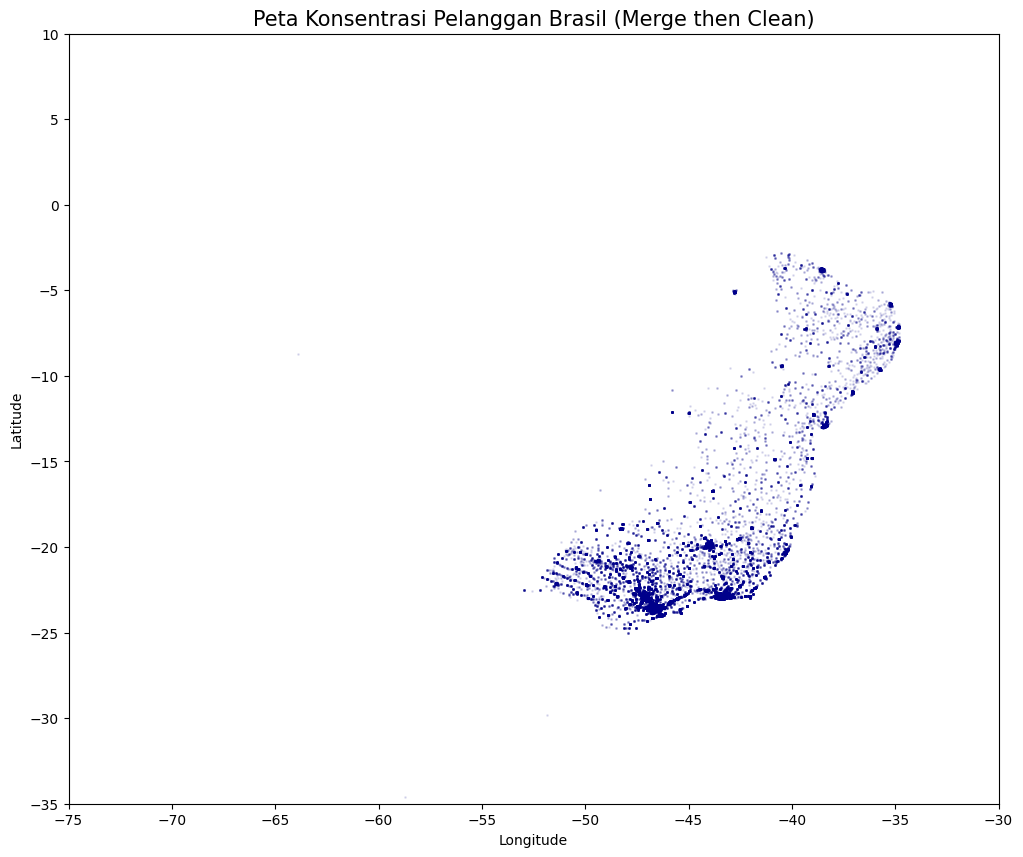

In [46]:
plt.figure(figsize=(12, 10))

# Plot titik koordinat pelanggan
plt.scatter(
    geo_cleaned_df['geolocation_lng'],
    geo_cleaned_df['geolocation_lat'],
    s=1,
    alpha=0.1,
    color='darkblue'
)

plt.title('Peta Konsentrasi Pelanggan Brasil (Merge then Clean)', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Fokuskan koordinat pada area Brasil
plt.xlim(-75, -30)
plt.ylim(-35, 10)

plt.grid(False)
plt.show()

## Conclusion

- Periode 2017-2018 analisis menunjukkan bahwa kategori produk yang berhubungan dengan gaya hidup dan kebutuhan rumah tangga, seperti health_beauty, watches_gifts, dan bed_bath_table, merupakan kontributor pendapatan terbesar bagi perusahaan. Meskipun pendapatan penjualan sangat tinggi, tingkat kepuasan pelanggan terpantau stabil yang mengindikasikan bahwa tingginya minat pasar belum sepenuhnya dibarengi dengan pengalaman berbelanja yang sempurna.
- Secara geografis, tahun 2017-2018 aktivitas perdagangan sangat terpusat di wilayah Tenggara Brasil, khususnya di negara bagian São Paulo (SP) yang mendominasi jumlah pesanan secara signifikan dibandingkan dengan wilayah lainnya. Namun, dominasi pasar ini tidak berbanding lurus dengan kesetiaan pelanggan, mengingat data menunjukkan bahwa 97% pelanggan adalah pembeli satu kali (single buyer) dan hanya 3% yang melakukan pembelian ulang (repeat order). Hal ini mengungkap tantangan besar dalam hal retensi pelanggan, di mana tingginya biaya pengiriman (outlier freight value) ke wilayah pedalaman dan ketergantungan pada strategi menarik pengguna baru menjadi penghambat utama terciptanya pertumbuhan bisnis yang berkelanjutan melalui basis pelanggan setia.